# LLM Based Review Handling Workflow
## Conditional workflow using LangGraph

In [56]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [57]:
# Define Model
from langchain_openai import ChatOpenAI

model = ChatOpenAI(    
    base_url="http://localhost:12434/engines/v1",
    api_key="docker", 
    temperature=0, 
    model = "ai/smollm2:360M-Q4_K_M")

In [58]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the customer review")

In [59]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="The category of the issue mentioned in the customer review")
    tone: Literal["Angry", "Frustrated", "Disapointed", "Calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["Low", "Medium", "High"] = Field(description="How urgency or critical the issue appear to be")

In [60]:
# Define strucutred model
sentiment_structured_model = model.with_structured_output(SentimentSchema)
diagnosis_structured_model = model.with_structured_output(DiagnosisSchema)

In [61]:
# review = f"Give me the review sentiment for: The software is too bad."
# result = structured_model.invoke(review)
# print(result)

In [62]:
# Define State
class AgentState(TypedDict):
    review: str    
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [63]:
def find_sentiments(state: AgentState):
    review = state['review']
    prompt = f"For the following review find out the sentiment.\n\n #Review: {review}"
    sentiment = sentiment_structured_model.invoke(prompt).sentiment
    return {"sentiment": sentiment}

def run_diagnosis(state: AgentState):
    review = state['review']
    prompt = f"""
                Diagnose this negative review:\n\n
                #Review: {review}
                \n\n Return issue_type, tone, and urgency. 
              """
    diagnosis = diagnosis_structured_model.invoke(prompt)
    return {"diagnosis": diagnosis.model_dump()}

def negative_response(state: AgentState):
    review = state['review']
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.\n\n
             The user had {diagnosis['issue_type']} issue, sounded {diagnosis['tone']} and marked urgency as {diagnosis['urgency']}.
             \n\n
             #Review: {review}
             \n\n
             Write empathetic, helpful resolution message.
             """
    response = model.invoke(prompt).content
    return {'response': response}

def positive_response(state: AgentState):
    review = state['review']
    prompt = f"""Write a warm thank-you message in response to the review.\n\n
             #Review: {review}
             \n\n Also kindly ask the use to leave feedback on our website.
             """
    response = model.invoke(prompt).content
    return {'response': response}

def check_condition(state: AgentState) -> Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == "positive":
        return "positive_response"
    return "run_diagnosis"

In [64]:
# Define Graph
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("find_sentiments", find_sentiments)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("positive_response", positive_response)
graph.add_node("negative_response", negative_response)

# Add edges
graph.add_edge(START, "find_sentiments")
graph.add_conditional_edges("find_sentiments", check_condition)
graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("positive_response", END)
graph.add_edge("negative_response", END)

# compile
workflow = graph.compile()

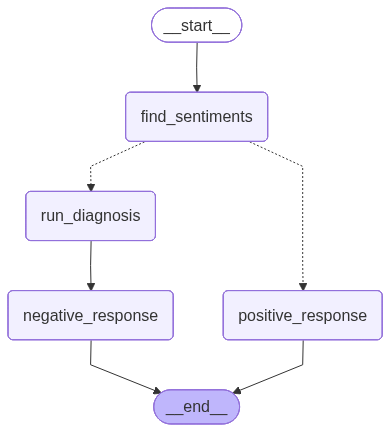

In [65]:
# visualize graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [66]:
# Invoke 
ineffective_chatbot_experience = f"""
        I tried using their chatbot, but it didn’t understand my issue and sent me in circles. Total waste of time!
        """
initial_state = {
    "review": ineffective_chatbot_experience
}

final_state = workflow.invoke(initial_state)
print(final_state['diagnosis'])
print(final_state['response'])


{'issue_type': 'Support', 'tone': 'Disapointed', 'urgency': 'High'}
Hi [User],

I’m so sorry to hear that you’re experiencing a support issue. I completely understand how frustrating and time-consuming it can be when you’re trying to resolve a problem. I’m here to help and want to make sure you feel supported and understood.

Could you please let me know what happened and how you’re feeling? I’m happy to listen and help in any way I can. If you need any additional assistance or have any questions, just let me know.

I’m looking forward to helping you through this and making things right.

Best regards,

[Your Name]

[Your Contact Information]


In [67]:
# Invoke 
product_delivery_experience = f"""
        Packaging was neat, the item worked perfectly, and customer support replied within hours.
        """
initial_state = {
    "review": product_delivery_experience
}

final_state = workflow.invoke(initial_state)
print(final_state['response'])

Dear [Customer's Name],

Thank you so much for your kind words about our product. I'm thrilled to hear that you found our packaging and the item to be neat and effective. Your feedback is incredibly valuable, and I'm sure it will help us improve our products and services in the future.

I'd like to extend my sincere thanks for your patience and understanding during our call. It's always a pleasure to have customers like you who appreciate the effort we put into our products.

I'd like to personally thank our customer support team for their prompt and helpful response. It's a big help to have someone who cares about our customers and is always available to assist them.

I hope you'll consider leaving a review on our website. Your feedback will help us grow and improve our offerings.

Thank you again for your time and consideration.

Best regards,

[Your Name]

[Your Contact Information]
